In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from data.visualize import plot_stations_on_dem, markers_from_stations_table

import peakweather

print("PeakWeather version ",peakweather.__version__)

from peakweather import PeakWeatherDataset

#Load Local Dataset
# Exclude: rain gauge stations (142) & sunshine variable
ds = PeakWeatherDataset(root="/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset",
                        parameters = ["temperature",
                                      "pressure",
                                      "humidity",
                                      "wind_speed",
                                      "wind_gust",
                                      "wind_direction",
                                      "precipitation",
                                      ],
                        extended_topo_vars="DEM",
                        compute_uv = True,
                        freq = "d",
                        station_type="meteo_station")

PeakWeather version  0.2.1


In [2]:
df, mask = ds.get_observations(
    return_mask=True,
)

long_df = mask.stack(0).rename_axis(["datetime","nat_abbr"]).reset_index()
df_time = long_df.groupby(["datetime"]).sum().drop(columns=["nat_abbr"]).reset_index().drop(columns = ["wind_speed", "wind_direction"])
df_station = long_df.drop(columns=["datetime"]).groupby(["nat_abbr"]).sum().reset_index().drop(columns = ["wind_speed", "wind_direction"])

variables = df_station.columns[df_station.columns != 'nat_abbr']

In [3]:
variables

Index(['humidity', 'precipitation', 'pressure', 'temperature', 'wind_gust',
       'wind_u', 'wind_v'],
      dtype='str', name='name')

In [4]:
# Count how many variables are <1600 for each station
df_station["count_true"] = (df_station[variables] < 1600).sum(axis=1)

print("Number of Stations with less than 50% data recorded ", len(df_station["count_true"] != 0))
df_station[df_station["count_true"] != 0].sort_values("count_true", ascending=False)

Number of Stations with less than 50% data recorded  156


name,nat_abbr,humidity,precipitation,pressure,temperature,wind_gust,wind_u,wind_v,count_true
110,PFA,1041,1041,1041,1041,1041,1041,1041,7
1,AEG,0,0,0,0,3205,3205,3205,4
115,PRE,0,0,0,0,3205,3205,3205,4
82,LAC,3207,3208,0,3207,0,0,0,4
116,PSI,3209,3209,3209,3209,0,0,0,3
66,GRC,3208,3207,3209,3208,0,0,0,3
83,LAE,3207,0,3209,3207,3163,1309,1309,3
140,STK,0,0,3209,0,3208,3208,3208,3
129,SCM,0,0,3209,0,3204,3204,3204,3
118,QUI,0,0,3209,0,3209,3209,3209,3


In [5]:
valid_stations = df_station[df_station["count_true"] == 0]["nat_abbr"].values
missing_one = df_station[df_station["count_true"] == 1]["nat_abbr"].values

station_list = np.concatenate([missing_one, valid_stations, ["PFA"]])

no_multi = df_station.loc[~df_station["nat_abbr"].isin(station_list), "nat_abbr"].values

In [6]:
PATH_SWISSSHAPE = "/Users/aureliedejong/Documents/ETH/_DAS Project/swissboundaries3d_2026-01_2056_5728.shp.zip"

valid_markers = markers_from_stations_table(
    ds.stations_table, station_ids = valid_stations, default_color="white",
    size=50, marker="o",
    label="Valid stations",
)



In [7]:
one_markers = markers_from_stations_table(
    ds.stations_table,
    station_ids = missing_one, default_color="lightcoral",
    marker="o", size=50, zorder=20,
    label="Missing One Variable",
)

other_markers = markers_from_stations_table(
    ds.stations_table,
    station_ids = no_multi, default_color="red",
    marker="o", size=50, zorder=20,
    label="Missing Multiple Variables",
)



In [8]:
PFA_marker = markers_from_stations_table(
    ds.stations_table, station_ids = "PFA",   # or just "PFA"
    default_color = "darkred", marker="*", size=200, zorder=40,
    label="PFA",
)

/opt/anaconda3/envs/capstone/lib/python3.12/site-packages/pyproj/crs/_cf1x8.py:515: UserWarning: angle from rectified to skew grid parameter lost in conversion to CF
  warnings.warn(


<Axes: title={'center': 'Switzerland DEM with Station Overlay'}>

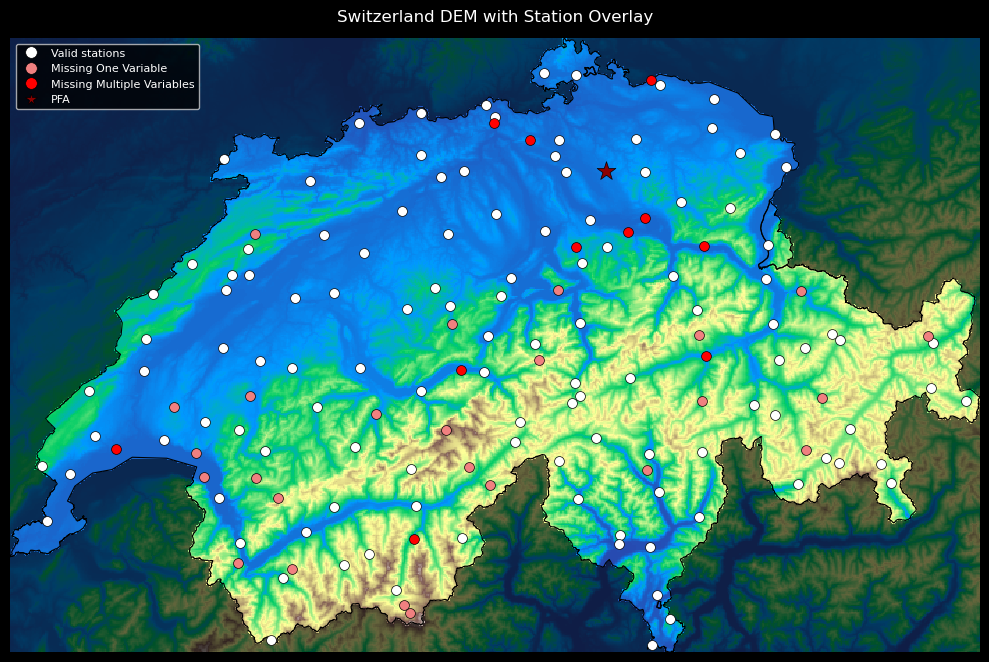

In [9]:
plot_stations_on_dem(
    ds,
    stations=valid_markers + one_markers + other_markers + PFA_marker,
    path_swissshape=PATH_SWISSSHAPE,
    #title="PeakWeather Meteo Stations — PFA highlighted",
)